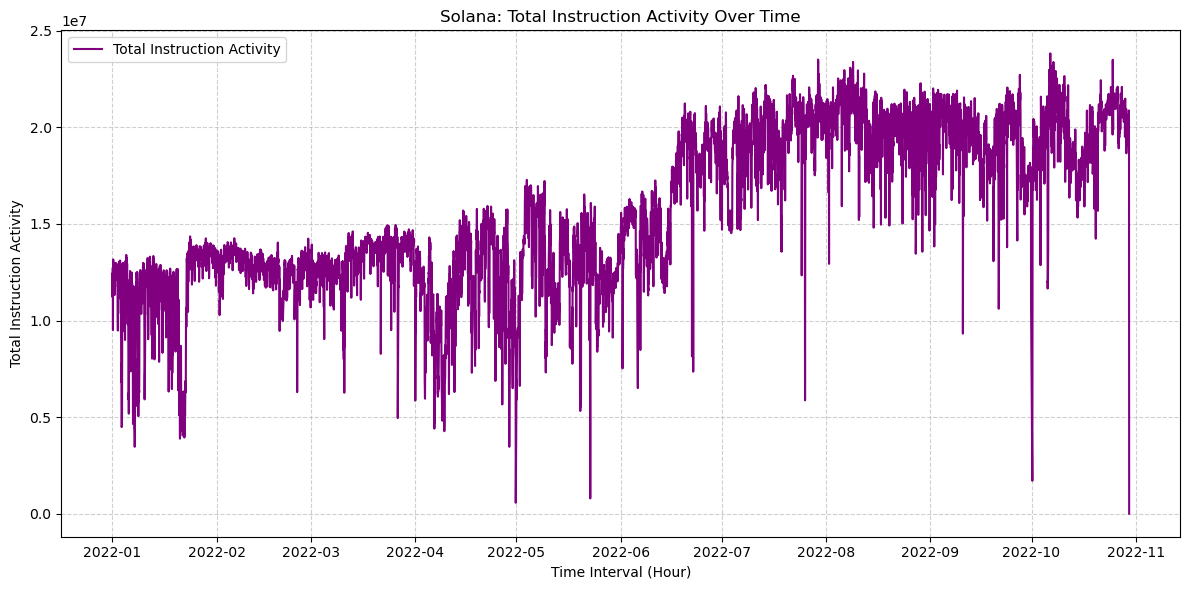

In [14]:
import matplotlib.pyplot as plt

# **Bayesian Cyber Attack Detection on Blockchains**

Across industry, companies are mandated to monitor their computer and application telemetry data for both regulatory (cybersecurity) and business purposes. For this reason, companies across industry spend millions on establishing their telemetry data – both through software that acts as a sensor on the machine or application and through the establishment of complex data management and analysis systems.

A niche and underexplored area of telemetry data exists in the Web3 space and information produced by blockchains and Web3 apps that sit on blockchains.

This component of the project seeks to define cyber threat detection problems on blockchains that can be solved by Bayesian statistics, to establish said data and then to execute some detections.



# **Solana Blockchain of Focus**

The primary blockchain we analyze in this analysis is the Solana blockchain and we do this through the public BigQuery datasets located here:

https://console.cloud.google.com/marketplace/product/bigquery-public-data/crypto-solana-mainnet-us



In [35]:
import pandas as pd

# Load the new CSV file
file_path = 'solana_attack_list.csv'
df2 = pd.read_csv(file_path)

# Select only the desired columns
columns_to_keep_2 = [
    'Attack target',
    'Loss Amount',
    'Attack Method',
    'Attack Time'
]
filtered_df2 = df2[columns_to_keep_2]

# Display the table in the notebook
from IPython.display import display
display(filtered_df2)

# Load the CSV file
file_path = 'web3_crypto_attacks_with_dates.csv'
df = pd.read_csv(file_path)

# Select the columns to keep
columns_to_keep = [
    'Attack type',
    'Platform / project',
    'Approx. damages',
    'Signal (volume/frequency change)',
    'Approximate date'
]
filtered_df = df[columns_to_keep]

# Filter for entries containing 'solana' (case insensitive)
filtered_df = filtered_df[
    filtered_df['Platform / project'].str.lower().str.contains('solana', na=False)
]

# Convert 'Approximate date' to datetime and sort (handles errors gracefully)
filtered_df['Approximate date'] = pd.to_datetime(filtered_df['Approximate date'], errors='coerce')
filtered_df = filtered_df.sort_values('Approximate date')

# Display the result
display(filtered_df)

,Attack target,Loss Amount,Attack Method,Attack Time
0,Solend,"$1,260,000",Oracle Attack,11/2/22
1,Mango,"$100,000,000",Flash Loan,10/11/22
2,TulipProtocol,"$2,500,000",Mango Attack,10/12/22
3,UXD Protocol,"$20,000,000",Mango Attack,10/12/22
4,OptiFi,"661,000 USDC",Operational Error,8/29/22
5,Nirvana,"$3,500,000",Flash Loan,7/28/22
6,Crema Finance,"$1,682,000",Flash Loan,7/3/22
7,Jet Protocol,Unknown,Unknown,3/30/22
8,Cashio,"$52,027,994",Hacker bypassed unverified accounts,3/23/22
9,Wormhole,"120,000 ETH",Developer enabled forged signatures via deprec...,2/2/22


/var/folders/9z/drb8jy35027dyvrwbg599ctw0000gn/T/ipykernel_18605/4239569958.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_df['Approximate date'] = pd.to_datetime(filtered_df['Approximate date'], errors='coerce')


,Attack type,Platform / project,Approx. damages,Signal (volume/frequency change),Approximate date
3,DDoS / spam on validators,Solana,No direct theft; economic impact via downtime ...,Sudden surge in TPS / RPC calls overwhelming v...,NaT
15,Web/API abuse on DeFi frontends,"Ethereum, Solana NFT mints",Users waste millions in aggregate gas across m...,Surges in HTTP requests to /mint plus massive ...,NaT


One important component of this analysis was selecting a propblem that could actually be monitored by baysian statistics.

Originally we considered the Wormhole issue. However, this is not an issue associated with a volume change of any feature of the datasets.

Instead, we pivoted to the incident associated with the second line of the second tabl

# **Solana Data Retrieval -- BigQuery Open Datasets**
We have 2 initial queries by which we retrieve data for this dataset. The first is a global query that builds an hourly timeseries to count the number of events in the dataset.

**Produce Timeseries for global data**
SELECT
  TIMESTAMP_TRUNC(block_timestamp, HOUR) AS time_interval_hour,
  COUNT(*) AS total_instruction_activity 
FROM `bigquery-public-data.crypto_solana_mainnet_us.Instructions` 
WHERE block_timestamp BETWEEN '2022-01-01 00:00:00' AND '2022-10-30 00:00:00'
GROUP BY time_interval_hour
ORDER BY time_interval_hour


**Produce Timeseries for 'mintTo' Instructions**
SELECT
  TIMESTAMP_TRUNC(block_timestamp, HOUR) AS time_interval_hour,
  COUNT(*) AS total_instruction_activity 
FROM `bigquery-public-data.crypto_solana_mainnet_us.Instructions` 
WHERE instruction_type = 'mintTo' 
AND block_timestamp BETWEEN '2022-01-01 00:00:00' AND '2022-10-30 00:00:00'
GROUP BY time_interval_hour
ORDER BY time_interval_hour

# **Global Data Analysis**

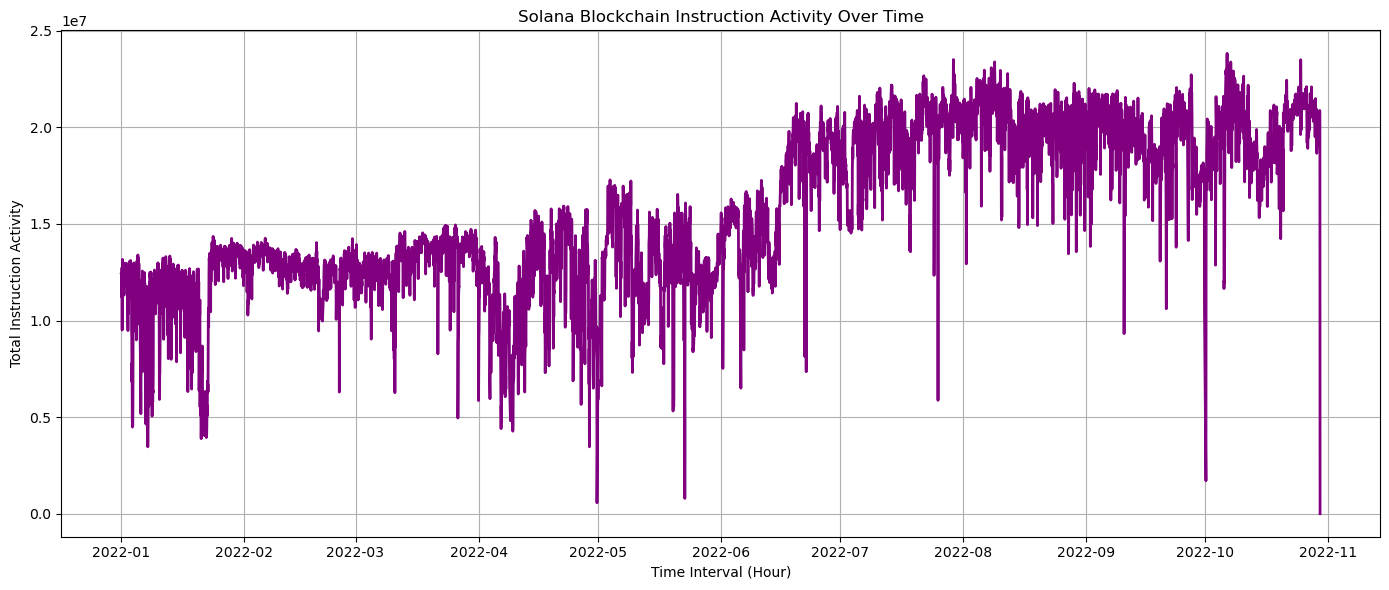

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'solana_blockchain_instructiondata_totalvol.csv'
df = pd.read_csv(file_path)

# Convert 'time_interval_hour' to datetime
df['time_interval_hour'] = pd.to_datetime(df['time_interval_hour'], errors='coerce')

# Plot total instruction activity vs time interval
plt.figure(figsize=(14, 6))
plt.plot(df['time_interval_hour'], df['total_instruction_activity'], color='purple', linewidth=2)
plt.title('Solana Blockchain Instruction Activity Over Time')
plt.xlabel('Time Interval (Hour)')
plt.ylabel('Total Instruction Activity')
plt.grid(True)
plt.tight_layout()
plt.show()

One thing notable about the global timeseries observed above is that there are numerous downspikes. 

These downspikes represent times that there was a large network outage. The one at the beginning of May 2025 is correlated with the NFT minting event of interest.


# ** BOT Overload Cyber Incident in April / May of 2022**


Sequential sampling (2 chains in 1 job)
INFO:pymc.sampling.mcmc:Sequential sampling (2 chains in 1 job)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Metropolis: [change_point]
INFO:pymc.sampling.mcmc:>Metropolis: [change_point]
>NUTS: [mu1, mu2, sigma1, sigma2]
INFO:pymc.sampling.mcmc:>NUTS: [mu1, mu2, sigma1, sigma2]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective s

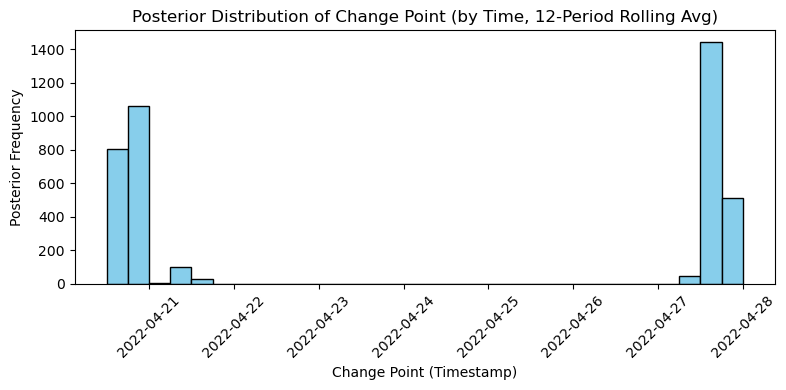

Most likely change point index: 918
Most likely change point timestamp: 2022-04-27 17:00:00+00:00


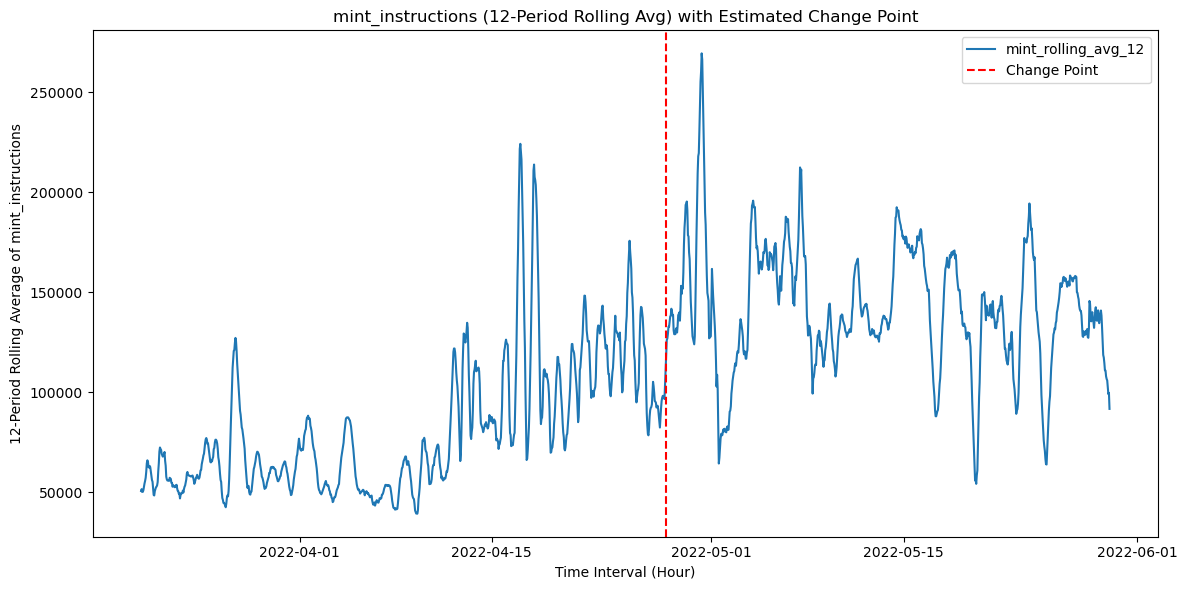

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

# Load your dataset and parse time column
df = pd.read_csv("solana_blocks_hourly2.csv")
df['time_interval_hour'] = pd.to_datetime(df['time_interval_hour'])

# Compute 12-period rolling average (including current period)
df['mint_rolling_avg_12'] = df['mint_instructions'].rolling(window=12, min_periods=12).mean()
df = df.dropna(subset=['mint_rolling_avg_12']).reset_index(drop=True)

mint_avg = df['mint_rolling_avg_12'].values
time = df['time_interval_hour']
n = len(mint_avg)

# Empirical priors (from rolling average column)
emp_mean = np.mean(mint_avg)
emp_std = np.std(mint_avg)

# Bayesian change point model
with pm.Model() as model:
    # Uniform prior for change point (any hour)
    change_point = pm.DiscreteUniform("change_point", lower=0, upper=n-1)
    
    # Priors for pre- and post-change means/variances
    mu1 = pm.Normal("mu1", mu=emp_mean, sigma=emp_std)
    mu2 = pm.Normal("mu2", mu=emp_mean, sigma=emp_std)
    sigma1 = pm.HalfNormal("sigma1", sigma=emp_std)
    sigma2 = pm.HalfNormal("sigma2", sigma=emp_std)

    # Likelihood: split data at change point
    idx = np.arange(n)
    mu = pm.math.switch(idx < change_point, mu1, mu2)
    sigma = pm.math.switch(idx < change_point, sigma1, sigma2)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=mint_avg)

    # MCMC sampling
    trace = pm.sample(2000, tune=2000, cores=1, random_seed=42, return_inferencedata=False)

# Posterior change point samples
change_points_samples = trace['change_point']

# Plot posterior distribution of the change point (indexed by timestamp)
plt.figure(figsize=(8,4))
plt.hist([time.iloc[i] for i in change_points_samples], bins=30, color='skyblue', edgecolor='k')
plt.xlabel("Change Point (Timestamp)")
plt.ylabel("Posterior Frequency")
plt.title("Posterior Distribution of Change Point (by Time, 12-Period Rolling Avg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Output modal estimate (most probable change point)
change_point_mode = np.bincount(change_points_samples).argmax()
change_point_time = time.iloc[change_point_mode]
print(f"Most likely change point index: {change_point_mode}")
print(f"Most likely change point timestamp: {change_point_time}")

# Plot the rolling average time series with change point overlay using timestamp
plt.figure(figsize=(12,6))
plt.plot(time, mint_avg, label='mint_rolling_avg_12')
plt.axvline(change_point_time, color='red', linestyle='--', label='Change Point')
plt.xlabel("Time Interval (Hour)")
plt.ylabel("12-Period Rolling Average of mint_instructions")
plt.title("mint_instructions (12-Period Rolling Avg) with Estimated Change Point")
plt.legend()
plt.tight_layout()
plt.show()

# ANALYSIS
In the above code, we run a MCMC bayesian changepoint detection to see if we can identify a shift in the mean of the timeseries associated with mint actions on solana.

The main event associated with the overloading of mint actions that took down the network was on the last day of April which can be associated with a spike in the time series visualization.

One reason this approach is useful is it seeks to identify a point in the series that represents a change in behavior of the underlying process that generates the data, so that there is a substantial difference between the mean prior to and after this process.
